In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data.loader import BinanceLoader
from src.data.bars import create_volume_bars
from src.features.microstructure import MicrostructureEngine
from src.alpha_engine.generator import HybridAlphaEngine
from src.evaluation.walk_forward import WalkForwardEvaluator
from src.risk.portfolio import TargetVolatilityRiskManager
from src.alpha_engine.optimizer import AlphaOptimizer

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
print('Скачиваем 1m данные BTCUSDT с Binance API...')
loader = BinanceLoader()
ticks = loader.fetch_historical(symbol='BTCUSDT', start='90 days ago UTC')
ticks['price'] = ticks['close']
print(f'Загружено {len(ticks)} минут (с {ticks.index[0].date()} по {ticks.index[-1].date()})')

Скачиваем 1m данные BTCUSDT с Binance API...
Загружено 129601 минут (с 2026-02-05 по 2026-05-06)


In [3]:
vol_threshold = ticks['volume'].mean() * 15
bars = create_volume_bars(ticks, volume_threshold=vol_threshold)
print(f'Сформировано {len(bars)} Volume Bars.')

engine_ms = MicrostructureEngine(window=10)
features_df = engine_ms.fit_transform(bars)
print(f'Данные с фичами: {features_df.shape}')

days_covered = (features_df.index[-1] - features_df.index[0]).days
bars_per_day  = len(features_df) / max(days_covered, 1)
bars_per_year = int(bars_per_day * 365.25)
print(f'Баров/день: {bars_per_day:.1f}  →  bars_per_year = {bars_per_year}')

display(features_df.head(3))

Сформировано 8451 Volume Bars.
Данные с фичами: (8431, 12)
Баров/день: 94.7  →  bars_per_year = 34600


,open,high,low,close,volume,log_ret,roll_measure,ofi_proxy,parkinson_vol,momentum_5,momentum_20,rsi_14
timestamp,,,,,,,,,,,,
2026-02-05 23:54:00,62946.30,63012.45,62936.33,63012.45,347.16090,-0.001887,234.789673,-126.434792,0.001844,-0.009186,-0.014890,17.174297
2026-02-05 23:57:00,63107.32,63107.32,62981.79,62981.79,190.54244,-0.000487,158.774440,-119.523641,0.001588,-0.009813,-0.020505,14.155939
2026-02-06 00:00:00,62802.36,63047.62,62802.36,63047.62,204.32044,0.001045,0.002409,-120.818235,0.001586,-0.006687,-0.017186,10.034088


In [4]:
from sklearn.preprocessing import StandardScaler
from src.koopman.edmd import EDMDKoopmanModel

feature_cols = ['log_ret', 'roll_measure', 'ofi_proxy', 'parkinson_vol']
train_w = 1000
results = []

max_start = len(features_df) - train_w - 150
if max_start <= 0:
    print('ВНИМАНИЕ: Слишком мало баров. Скачайте больше данных.')
else:
    for fold, start in enumerate(range(0, max_start, 150)):
        train = features_df.iloc[start : start + train_w]
        test  = features_df.iloc[start + train_w : start + train_w + 150]

        scaler = StandardScaler()
        train_sc = scaler.fit_transform(train[feature_cols].values)
        test_sc  = scaler.transform(test[feature_cols].values)

        model = EDMDKoopmanModel()
        model.fit(train_sc[:-1], train_sc[1:])

        n_min  = model.n_min_rows
        preds  = np.array([model.predict(test_sc[max(0, i - n_min + 1):i + 1], steps=1).flatten()[0] for i in range(len(test_sc) - 1)])
        actual = test_sc[1:, 0]

        sign_acc      = np.mean(np.sign(preds) == np.sign(actual))
        pred_mean_abs = np.mean(np.abs(preds))
        corr          = np.corrcoef(preds, actual)[0, 1]

        results.append({
            'fold':     fold + 1,
            'period':   f"{test.index[0].strftime('%m-%d %H:%M')} → {test.index[-1].strftime('%m-%d %H:%M')}",
            'sign_acc': round(sign_acc, 3),
            'corr':     round(corr, 4),
            'pred_abs': round(pred_mean_abs, 5),
        })

    diag_df = pd.DataFrame(results).set_index('fold')
    display(diag_df)
    print(f'\nСредняя точность знака : {diag_df["sign_acc"].mean():.1%}')
    print(f'Средняя корреляция     : {diag_df["corr"].mean():.4f}')

,period,sign_acc,corr,pred_abs
fold,,,,
1,02-11 14:39 → 02-12 18:32,0.544,0.0663,0.08246
2,02-12 18:41 → 02-14 12:35,0.470,-0.0617,0.08601
3,02-14 12:44 → 02-16 05:02,0.490,0.0077,0.06068
4,02-16 05:36 → 02-18 08:15,0.477,-0.0437,0.05499
5,02-18 08:37 → 02-20 09:48,0.497,0.0668,0.04913
6,02-20 10:10 → 02-22 14:41,0.503,-0.0569,0.07050
7,02-22 14:48 → 02-23 20:21,0.477,0.0629,0.03551
8,02-23 20:30 → 02-25 06:52,0.463,-0.0413,0.06447
9,02-25 07:14 → 02-26 12:25,0.463,-0.0625,0.05145



Средняя точность знака : 50.1%
Средняя корреляция     : 0.0168


In [5]:
TRAIN_WINDOW = 1000
TEST_WINDOW  = 150
COMMISSION   = 0.0002
SLIPPAGE     = 0.0001

risk_mgr = TargetVolatilityRiskManager(target_annual_vol=0.40, max_leverage=1.0)

param_grid = {
    'tda_window':     [15, 20],
    'tda_percentile': [88.0, 90.0, 92.0],
    'z_threshold':    [0.0],
    'z_quantile':     [0.70, 0.80],
    'direction_mode': ['rsi'],
    'rsi_oversold':   [30.0, 35.0, 40.0],
    'rsi_overbought': [60.0, 65.0, 70.0],
    'htf_k':          [10, 15],
}

opt = AlphaOptimizer(
    param_grid,
    train_window=TRAIN_WINDOW,
    test_window=TEST_WINDOW,
    commission=COMMISSION,
    slippage=SLIPPAGE,
    risk_manager=risk_mgr,
    verbose=True
)
results_df = opt.run(features_df)

print('\\n=== ТОП-5 КОМБИНАЦИИ ===')
display(
    results_df.head(5).style
    .format({'sharpe': '{:.3f}', 'total_return': '{:.2f}%', 'max_drawdown': '{:.2f}%'})
    .background_gradient(subset=['sharpe'], cmap='RdYlGn')
)




[1/216] Тест параметров: {'tda_window': 15, 'tda_percentile': 88.0, 'z_threshold': 0.0, 'z_quantile': 0.7, 'direction_mode': 'rsi', 'rsi_oversold': 30.0, 'rsi_overbought': 60.0, 'htf_k': 10}
         → Sharpe=-0.280  Return=-0.16%  MaxDD=-0.99%  Trades=70
[2/216] Тест параметров: {'tda_window': 15, 'tda_percentile': 88.0, 'z_threshold': 0.0, 'z_quantile': 0.7, 'direction_mode': 'rsi', 'rsi_oversold': 30.0, 'rsi_overbought': 60.0, 'htf_k': 15}
         → Sharpe=-2.810  Return=-1.31%  MaxDD=-1.57%  Trades=63
[3/216] Тест параметров: {'tda_window': 15, 'tda_percentile': 88.0, 'z_threshold': 0.0, 'z_quantile': 0.7, 'direction_mode': 'rsi', 'rsi_oversold': 30.0, 'rsi_overbought': 65.0, 'htf_k': 10}
         → Sharpe=-0.590  Return=-0.30%  MaxDD=-0.82%  Trades=60
[4/216] Тест параметров: {'tda_window': 15, 'tda_percentile': 88.0, 'z_threshold': 0.0, 'z_quantile': 0.7, 'direction_mode': 'rsi', 'rsi_oversold': 30.0, 'rsi_overbought': 65.0, 'htf_k': 15}
         → Sharpe=-2.240  Return=-0.97%  

,tda_window,tda_percentile,z_threshold,z_quantile,direction_mode,rsi_oversold,rsi_overbought,htf_k,sharpe,total_return,max_drawdown,n_trades
0,20,90.000000,0.000000,0.800000,rsi,30.000000,70.000000,15,1.580,0.53%,-0.48%,26
1,20,92.000000,0.000000,0.800000,rsi,30.000000,70.000000,15,1.580,0.53%,-0.48%,26
2,15,92.000000,0.000000,0.700000,rsi,30.000000,60.000000,10,1.550,0.76%,-0.65%,52
3,15,92.000000,0.000000,0.700000,rsi,30.000000,70.000000,10,1.520,0.63%,-0.49%,42
4,20,92.000000,0.000000,0.700000,rsi,30.000000,60.000000,10,1.410,0.80%,-0.89%,69


In [6]:
best = opt.best_params(top_n=1)[0]
print(f'Лучшие параметры: {best}')

best_engine = HybridAlphaEngine(**best)

evaluator = WalkForwardEvaluator(
    train_window=TRAIN_WINDOW,
    test_window=TEST_WINDOW,
    commission=COMMISSION,
    slippage=SLIPPAGE,
)

oos_best = evaluator.walk_forward_eval(
    features_df,
    best_engine.generate_signals,
    risk_manager=risk_mgr
)

print('\n=== МЕТРИКИ OOS ===')
print(WalkForwardEvaluator.get_summary(oos_best))
print(f'(bars_per_year использован: {bars_per_year})')


Лучшие параметры: {'tda_window': 20, 'tda_percentile': 90.0, 'z_threshold': 0.0, 'z_quantile': 0.8, 'direction_mode': 'rsi', 'rsi_oversold': 30.0, 'rsi_overbought': 70.0, 'htf_k': 15}

=== МЕТРИКИ OOS ===
{'Sharpe Ratio': 1.58, 'Max Drawdown': -0.48, 'Total Return': 0.53}
(bars_per_year использован: 34600)


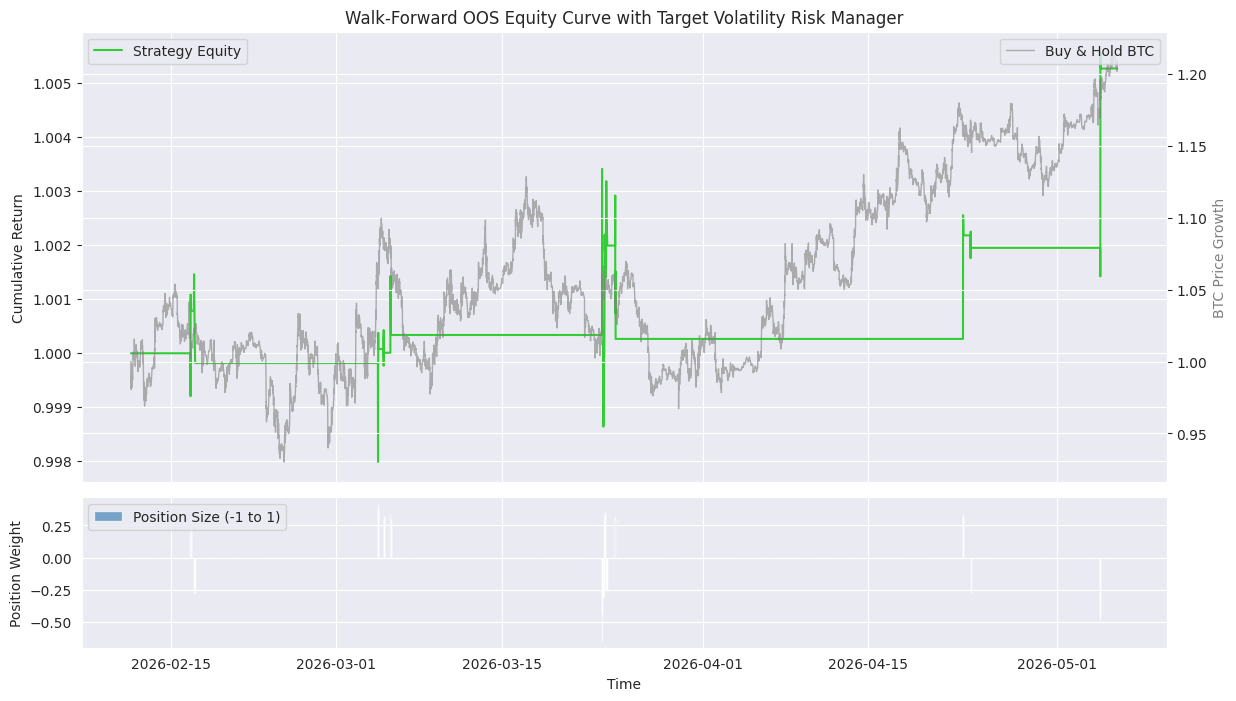

In [7]:
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax1.plot(oos_best.index, oos_best['equity_curve'], color='limegreen', lw=1.5, label='Strategy Equity')

btc_norm = oos_best['close'] / oos_best['close'].iloc[0]
ax1_r = ax1.twinx()
ax1_r.plot(oos_best.index, btc_norm, color='gray', lw=1, alpha=0.6, label='Buy & Hold BTC')
ax1_r.set_ylabel('BTC Price Growth', color='gray')

ax1.set_title('Walk-Forward OOS Equity Curve with Target Volatility Risk Manager')
ax1.set_ylabel('Cumulative Return')
ax1.legend(loc='upper left')
ax1_r.legend(loc='upper right')

ax2.bar(oos_best.index, oos_best['position'], color='steelblue', alpha=0.7, width=0.005, label='Position Size (-1 to 1)')
ax2.set_ylabel('Position Weight')
ax2.set_xlabel('Time')
ax2.legend(loc='upper left')

plt.setp(ax1.get_xticklabels(), visible=False)
plt.tight_layout()
plt.show()